# ЛР №2. Регрессия: построение первой модели машинного обучения

**Задача:** предсказать стоимость квартиры (`PriceMillion`) по её характеристикам.

В этой работе мы впервые проходим полный ML-pipeline: признаки → train/test → baseline → модель → прогноз → метрики → анализ ошибок.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("ai_housing_lab2.csv")
df.head()


,Area,Rooms,Floor,BuildingAge,MetroMinutes,District,Renovation,PriceMillion
0,48.9,1,22,36,10.4,Центр,Обычный,14.40
1,102.9,3,8,13,5.9,Центр,Обычный,30.35
2,82.7,3,2,43,21.3,Центр,Без ремонта,17.19
3,71.3,2,17,51,10.3,Юг,Хороший,17.58
4,69.5,3,23,34,12.0,Юг,Обычный,15.59


## Задание 1. Постановка задачи
Определите объект наблюдения, целевую переменную и признаки. Объясните, почему это задача **регрессии**, а не классификации.


# Объект набюдения квартиры с фиксированной стоимостью.

Целевая переменная: стоимость квартиры

Потому что целевая переменная это числовое значение, а не категория

In [ ]:
print(df.shape)
print(df.columns)
print(df.dtypes) 

(650, 8)
Index(['Area', 'Rooms', 'Floor', 'BuildingAge', 'MetroMinutes', 'District',
       'Renovation', 'PriceMillion'],
      dtype='str')
Area            float64
Rooms             int64
Floor             int64
BuildingAge       int64
MetroMinutes    float64
District            str
Renovation          str
PriceMillion    float64
dtype: object


## Задание 2. X и y
Отделите `PriceMillion` от признаков. Определите числовые и категориальные столбцы.


In [29]:
X = df.drop(columns="PriceMillion")
y = df["PriceMillion"]

cat_cols = ["District", "Renovation"]
num_cols = [
"Area", "Rooms", "Floor",
"BuildingAge", "MetroMinutes"
]

## Задание 3. Train/test split
Разделите данные в отношении 80/20 с `random_state=42`. Покажите размеры выборок. Объясните, зачем тестовые данные не должны участвовать в обучении.


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

## Задание 4. Baseline
Создайте простейший прогноз: для каждого объекта предсказывайте **среднюю цену обучающей выборки**. Рассчитайте MAE и RMSE. Эти значения станут точкой отсчёта.


In [31]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

baseline_pred = np.full(
len(y_test),
y_train.mean()
)

baseline_mae = mean_absolute_error(
y_test, baseline_pred
)
baseline_rmse = mean_squared_error(
y_test, baseline_pred
) ** 0.5

baseline_r2 = r2_score(
y_test, baseline_pred
)
print(baseline_mae, baseline_rmse, baseline_r2)

6.555439349112427 7.652992047072777 -0.005648562396039392


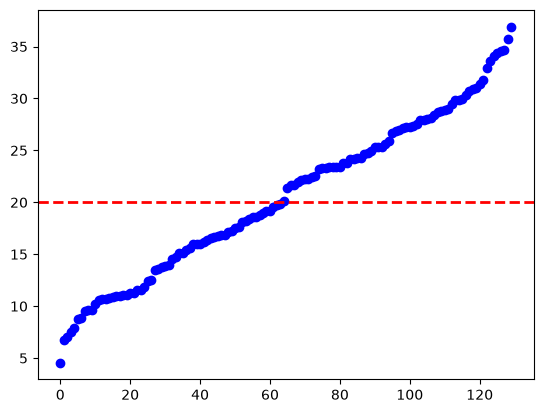

In [32]:
import numpy as np

mean_price = y_train.mean()


sorted_indices = np.argsort(y_test)

fig, ax = plt.subplots()

ax.scatter(range(len(y_test)), y_test.values[sorted_indices], 
            color='blue')

ax.axhline(y=mean_price, color='red', linestyle='--', linewidth=2)


## Задание 5. Linear Regression
Создайте preprocessing через `ColumnTransformer`: категориальные признаки кодируйте `OneHotEncoder(handle_unknown='ignore')`, числовые передавайте без изменения. Объедините preprocessing и `LinearRegression()` в `Pipeline`, обучите модель.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# препроцессинг
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# cоздаем пайплайн, который сначала применяет preprocessor, а затем LinearRegression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# обучаем пайплайн на тренировочных данных
model_pipeline.fit(X_train, y_train)

print("Модель обучена! Йоу!")

Модель успешно обучена!


## Задание 6. Метрики
Получите прогноз на test и вычислите:
- MAE;
- RMSE;
- R².

Сравните MAE/RMSE с baseline. Объясните метрики своими словами и укажите единицы измерения MAE/RMSE.


y_pred=array([21.82026085, 20.45634606, 27.9903428 , 12.02490252, 27.63595304,
       17.51694572, 23.84602097, 26.79780945, 11.20529017,  7.67389596,
       12.18238812, 10.9516113 , 13.55827805, 25.38797399, 19.68939472,
       10.93734488, 23.44997863,  7.76734565, 16.40648448, 26.30572648,
       29.5976719 , 11.0969155 , 18.55278194, 17.23661548, 24.17725361,
       24.36150469, 12.35137967, 22.56106745, 13.72391532, 25.79304552,
       23.42196384, 24.85440037, 30.46542631, 27.44085221, 29.50864435,
       26.2251392 , 22.89493521, 18.7000449 , 12.06855121, 15.85791716,
        8.06678906, 27.43048023, 21.0660156 , 10.98937281, 25.76137778,
       18.18704291, 16.93598282, 30.85997853, 34.75495652, 23.3464863 ,
       18.48066389, 30.16554446, 18.47119172, 12.06896779, 18.4918241 ,
       33.07412901, 30.4111836 ,  8.34438731, 12.0332236 , 24.25451411,
        9.38204043, 15.70103813, 11.8481872 , 14.29976961, 26.50430071,
       34.08070776, 13.06291531, 19.4169206 , 28.74795484

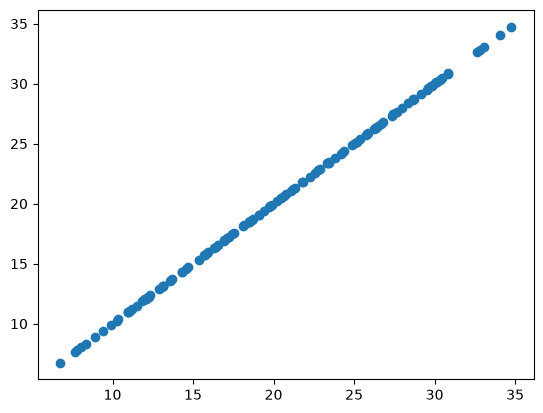

In [34]:
y_pred = model_pipeline.predict(X_test)
mae_pred = mean_absolute_error(y_test, y_pred)
mse_pred = mean_squared_error(y_test, y_pred)
rmse_pred = mse_pred ** 0.5
r2_pred = r2_score(y_test, y_pred)

plt_2 = plt.scatter(y_pred, y_pred)


print(f"{y_pred=}, {mae_pred=}, {mse_pred=}, {rmse_pred=}, {r2_pred=},")

In [35]:
metrics_df = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R²'],
    'Baseline': [baseline_mae, baseline_rmse, baseline_r2], 
    'Наша модель': [mae_pred, rmse_pred, r2_pred]
})

print(metrics_df)

  Метрика  Baseline  Наша модель
0     MAE  6.555439     1.840226
1    RMSE  7.652992     2.329113
2      R² -0.005649     0.906854


Честно говоря вот на этом этапе мне пришлось очень много погуглить, потому что объяснений из файлов вообще недостаточно. Непонятно главное что для чего мы ищем, что чем является, почему именно так.

### Задания 7 и 8 делали Вики

## Задание 7. Факт и прогноз
Постройте scatter plot: по X — реальные цены, по Y — прогноз. Добавьте диагональ идеального прогноза `y=x`. Чем ближе точки к диагонали, тем точнее модель.


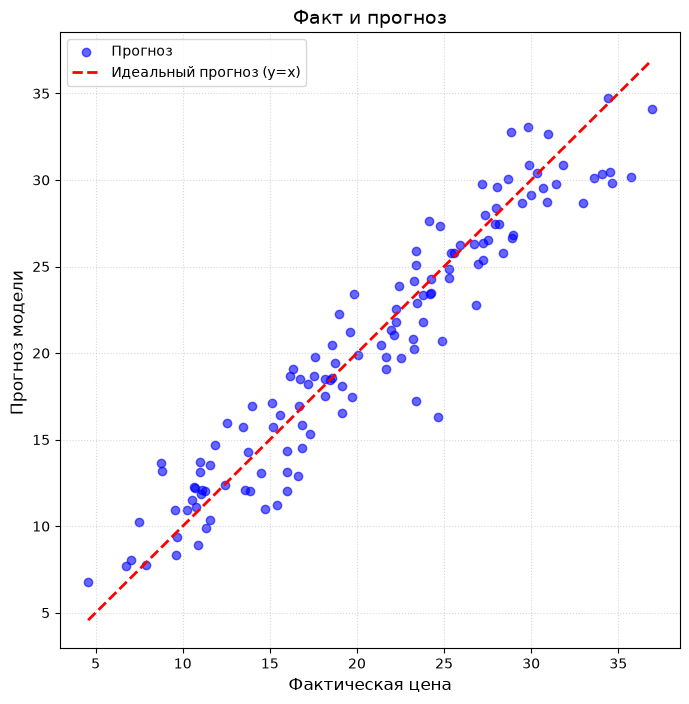

In [36]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Прогноз')


lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())

plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Идеальный прогноз (y=x)')

plt.xlabel("Фактическая цена", fontsize=12)
plt.ylabel("Прогноз модели ", fontsize=12)
plt.title("Факт и прогноз", fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

## Задание 8. Ошибки модели
Создайте таблицу `Actual`, `Predicted`, `Error`, `AbsError`. Найдите 10 объектов с наибольшей абсолютной ошибкой. Есть ли у них общие особенности?


In [37]:

errors_df = X_test.copy().reset_index(drop=True)
errors_df['Actual'] = y_test.reset_index(drop=True).values
errors_df['Predicted'] = y_pred
errors_df['Error'] = errors_df['Predicted'] - errors_df['Actual']
errors_df['AbsError'] = errors_df['Error'].abs()

top_10 = errors_df.nlargest(10, 'AbsError')
print(top_10[['Area', 'Rooms', 'District', 'Renovation', 'Actual', 'Predicted', 'Error', 'AbsError']])

      Area  Rooms District   Renovation  Actual  Predicted     Error  AbsError
90    65.6      1    Запад      Обычный   24.63  16.325473 -8.304527  8.304527
23    83.0      4    Запад  Без ремонта   23.37  17.236615 -6.133385  6.133385
51   135.5      4       Юг      Хороший   35.72  30.165544 -5.554456  5.554456
100   47.5      1    Север      Хороший    8.73  13.647548  4.917548  4.917548
87   137.3      6       Юг      Обычный   34.65  29.840929 -4.809071  4.809071
85    34.4      1   Восток      Хороший    8.82  13.165369  4.345369  4.345369
104  132.1      4   Восток      Хороший   32.95  28.647627 -4.302373  4.302373
81    98.0      3       Юг      Обычный   24.90  20.668894 -4.231106  4.231106
8     51.8      1   Восток      Обычный   15.39  11.205290 -4.184710  4.184710
32   137.5      5    Север      Обычный   34.53  30.465426 -4.064574  4.064574


## Задание 9. Эксперимент с признаками
Обучите минимум три версии:
1. только `Area`;
2. только числовые признаки;
3. все признаки.

Для каждой запишите MAE, RMSE, R². Сделайте вывод: всегда ли добавление признаков улучшает модель?


In [38]:

# только площадь
model_area = LinearRegression()
model_area.fit(X_train[['Area']], y_train)
y_pred_area = model_area.predict(X_test[['Area']])

mae_area = mean_absolute_error(y_test, y_pred_area)
rmse_area = mean_squared_error(y_test, y_pred_area) ** 0.5
r2_area = r2_score(y_test, y_pred_area)

# только числовые признаки
model_num = LinearRegression()
model_num.fit(X_train[num_cols], y_train)
y_pred_num = model_num.predict(X_test[num_cols])

mae_num = mean_absolute_error(y_test, y_pred_num)
rmse_num = mean_squared_error(y_test, y_pred_num) ** 0.5
r2_num = r2_score(y_test, y_pred_num)

# для 3-ей версии все метрики посчитаны в задании 6 (mae_pred, rmse_pred, r2_pred)

exp_df = pd.DataFrame({
    'Версия': ['Только Area', 'Числовые без категорий', 'Все признаки'],
    'MAE': [mae_area, mae_num, mae_pred],
    'RMSE': [rmse_area, rmse_num, rmse_pred],
    'R²': [r2_area, r2_num, r2_pred],
})
print(exp_df)

                   Версия       MAE      RMSE        R²
0             Только Area  2.389898  2.931484  0.852443
1  Числовые без категорий  2.280212  2.755551  0.869623
2            Все признаки  1.840226  2.329113  0.906854


## Задание 10. Прогноз для новых объектов
Создайте DataFrame минимум из трёх вымышленных квартир и получите прогноз цены. Один объект сделайте близким к типичным данным, другой — дорогим, третий — необычным/пограничным. Объясните, почему прогноз за пределами диапазона обучающих данных следует трактовать осторожно.


In [39]:
new_apartments = pd.DataFrame([
    # типичная
    {'Area': 85.0, 'Rooms': 3, 'Floor': 11, 'BuildingAge': 25,
     'MetroMinutes': 15.0, 'District': 'Север', 'Renovation': 'Обычный'},
    # дорогая
    {'Area': 140.0, 'Rooms': 6, 'Floor': 24, 'BuildingAge': 2,
     'MetroMinutes': 3.0, 'District': 'Центр', 'Renovation': 'Хороший'},
    # необычная
    {'Area': 300.0, 'Rooms': 12, 'Floor': 60, 'BuildingAge': 120,
     'MetroMinutes': 90.0, 'District': 'Юг', 'Renovation': 'Без ремонта'},
])

# Тут я словил ошибку коннекта scikit и пандаса, нашёл вроде способ как это решается, но всё равно до конца не понял в чём конфликт был. Что-то на уровне типизации
# new_apartments['PredictedPrice'] = model_pipeline.predict(new_apartments)

predictions = pd.Series(
    model_pipeline.predict(new_apartments), 
    index=new_apartments.index
)
new_apartments['PredictedPrice'] = predictions

print(new_apartments)

    Area  Rooms  Floor  BuildingAge  MetroMinutes District   Renovation  \
0   85.0      3     11           25          15.0    Север      Обычный   
1  140.0      6     24            2           3.0    Центр      Хороший   
2  300.0     12     60          120          90.0       Юг  Без ремонта   

   PredictedPrice  
0       19.030511  
1       38.494514  
2       52.542608  


## Итог
Ответьте:
1. Насколько модель лучше baseline?
2. Какая метрика наиболее понятна в единицах задачи?
3. Что означает R²?
4. Какие объекты модель предсказывает хуже?
5. Почему хорошая метрика на test ещё не доказывает, что модель готова к реальной эксплуатации?


# Итоги: 

1. Модель гораздо лучше baseline. Baseline тупо всем предсказывал среднюю цену. То есть в среднем промахиваемся меньше чем на 2 миллиона и объясняем 91% разброса цен.

2. Наверное MAE. Потому что она в тех же единицах, что и задача и читается сразу, типо в среднем ошибка ~1.84 млн. RMSE тоже в единицах цены, но из-за возведения в квадрат она сильнее штрафует за крупные промахи.

3. R^2 = 0.907 означает, что модель объясняет 90.7% разброса цен на тестовой выборке. Остальные 9% модель не поймала. Это я так понимаю либо шум, либо факторы, которых просто нет в данных.

4. маленькие квартиры, которые стоят дорого (площадь 65 м^2 при цене 24.6 млн модель выдала 16.3), и большие квартиры с плохим ремонтом. То есть там, где цена не выводится прямо из признаков, а зависит от чего-то неучтённого. Можно как вариант обложить большим количеством параметров, но в конетксте квартир это будет очень субъективно, когда для бабушкиного ремонта поставят типо хороший. Для кого-то он реально хороший.

5. Потому что метрика на test считается на данных того же распределения, что и обучение. в боевых условиях квартира с признаками вне диапазона (как у меня в задании 10 Area 300 при максимуме 145), новая невиданная категория района/ремонта, или просто рынок меняется. Линейная модель на таких объектах тупо продолжает прямую и выдаёт механический расчёт (52.5 млн за нереальную квартиру). по факту получается что на данных, похожих на обучающие модель работает, но для реальности сомнтительно.